<a href="https://colab.research.google.com/github/neerajpkpk/codsoft_project/blob/main/examples/vision/ipynb/handwriting_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwriting recognition

**Authors:** [A_K_Nain](https://twitter.com/A_K_Nain), [Sayak Paul](https://twitter.com/RisingSayak)<br>
**Date created:** 2021/08/16<br>
**Last modified:** 2025/09/29<br>
**Description:** Training a handwriting recognition model with variable-length sequences.

## Introduction

This example shows how the [Captcha OCR](https://keras.io/examples/vision/captcha_ocr/)
example can be extended to the
[IAM Dataset](https://fki.tic.heia-fr.ch/databases/iam-handwriting-database),
which has variable length ground-truth targets. Each sample in the dataset is an image of some
handwritten text, and its corresponding target is the string present in the image.
The IAM Dataset is widely used across many OCR benchmarks, so we hope this example can serve as a
good starting point for building OCR systems.

## Data collection

In [7]:
!wget -q https://github.com/sayakpaul/Handwriting-Recognizer-in-Keras/releases/download/v1.0.0/IAM_Words.zip
!unzip -qq IAM_Words.zip
!
!mkdir data
!mkdir data/words
!tar -xf IAM_Words/words.tgz -C data/words
!mv IAM_Words/words.txt data

Preview how the dataset is organized. Lines prepended by "#" are just metadata information.

In [8]:
!head -20 data/words.txt

#--- words.txt ---------------------------------------------------------------#
#
# iam database word information
#
# format: a01-000u-00-00 ok 154 1 408 768 27 51 AT A
#
#     a01-000u-00-00  -> word id for line 00 in form a01-000u
#     ok              -> result of word segmentation
#                            ok: word was correctly
#                            er: segmentation of word can be bad
#
#     154             -> graylevel to binarize the line containing this word
#     1               -> number of components for this word
#     408 768 27 51   -> bounding box around this word in x,y,w,h format
#     AT              -> the grammatical tag for this word, see the
#                        file tagset.txt for an explanation
#     A               -> the transcription for this word
#
a01-000u-00-00 ok 154 408 768 27 51 AT A
a01-000u-00-01 ok 154 507 766 213 48 NN MOVE


## Imports

In [9]:
import keras
from keras.layers import StringLookup
from keras import ops
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import os

np.random.seed(42)
keras.utils.set_random_seed(42)

## Dataset splitting

In [10]:
base_path = "data"
words_list = []

words = open(f"{base_path}/words.txt", "r").readlines()
for line in words:
    if line[0] == "#":
        continue
    if line.split(" ")[1] != "err":  # We don't need to deal with errored entries.
        words_list.append(line)

len(words_list)

np.random.shuffle(words_list)

We will split the dataset into three subsets with a 90:5:5 ratio (train:validation:test).

In [11]:
split_idx = int(0.9 * len(words_list))
train_samples = words_list[:split_idx]
test_samples = words_list[split_idx:]

val_split_idx = int(0.5 * len(test_samples))
validation_samples = test_samples[:val_split_idx]
test_samples = test_samples[val_split_idx:]

assert len(words_list) == len(train_samples) + len(validation_samples) + len(
    test_samples
)

print(f"Total training samples: {len(train_samples)}")
print(f"Total validation samples: {len(validation_samples)}")
print(f"Total test samples: {len(test_samples)}")

Total training samples: 86810
Total validation samples: 4823
Total test samples: 4823


## Data input pipeline

We start building our data input pipeline by first preparing the image paths.

In [12]:
base_image_path = os.path.join(base_path, "words")


def get_image_paths_and_labels(samples):
    paths = []
    corrected_samples = []
    for i, file_line in enumerate(samples):
        line_split = file_line.strip()
        line_split = line_split.split(" ")

        # Each line split will have this format for the corresponding image:
        # part1/part1-part2/part1-part2-part3.png
        image_name = line_split[0]
        partI = image_name.split("-")[0]
        partII = image_name.split("-")[1]
        img_path = os.path.join(
            base_image_path, partI, partI + "-" + partII, image_name + ".png"
        )
        if os.path.getsize(img_path):
            paths.append(img_path)
            corrected_samples.append(file_line.split("\n")[0])

    return paths, corrected_samples


train_img_paths, train_labels = get_image_paths_and_labels(train_samples)
validation_img_paths, validation_labels = get_image_paths_and_labels(validation_samples)
test_img_paths, test_labels = get_image_paths_and_labels(test_samples)

Then we prepare the ground-truth labels.

In [13]:
# Find maximum length and the size of the vocabulary in the training data.
train_labels_cleaned = []
characters = set()
max_len = 0

for label in train_labels:
    label = label.split(" ")[-1].strip()
    for char in label:
        characters.add(char)

    max_len = max(max_len, len(label))
    train_labels_cleaned.append(label)

characters = sorted(list(characters))

print("Maximum length: ", max_len)
print("Vocab size: ", len(characters))

# Check some label samples.
train_labels_cleaned[:10]

Maximum length:  21
Vocab size:  78


['sure',
 'he',
 'during',
 'of',
 'booty',
 'gastronomy',
 'boy',
 'The',
 'and',
 'in']

Now we clean the validation and the test labels as well.

In [14]:
def clean_labels(labels):
    cleaned_labels = []
    for label in labels:
        label = label.split(" ")[-1].strip()
        cleaned_labels.append(label)
    return cleaned_labels


validation_labels_cleaned = clean_labels(validation_labels)
test_labels_cleaned = clean_labels(test_labels)

### Building the character vocabulary

Keras provides different preprocessing layers to deal with different modalities of data.
[This guide](https://keras.io/api/layers/preprocessing_layers/) provides a comprehensive introduction.
Our example involves preprocessing labels at the character
level. This means that if there are two labels, e.g. "cat" and "dog", then our character
vocabulary should be {a, c, d, g, o, t} (without any special tokens). We use the
[`StringLookup`](https://keras.io/api/layers/preprocessing_layers/categorical/string_lookup/)
layer for this purpose.

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

# Mapping characters to integers.
char_to_num = StringLookup(vocabulary=list(characters), mask_token=None)

# Mapping integers back to original characters.
num_to_char = StringLookup(
    vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
)

### Resizing images without distortion

Instead of square images, many OCR models work with rectangular images. This will become
clearer in a moment when we will visualize a few samples from the dataset. While
aspect-unaware resizing square images does not introduce a significant amount of
distortion this is not the case for rectangular images. But resizing images to a uniform
size is a requirement for mini-batching. So we need to perform our resizing such that
the following criteria are met:

* Aspect ratio is preserved.
* Content of the images is not affected.

In [16]:
def distortion_free_resize(image, img_size):
    w, h = img_size
    image = tf.image.resize(image, size=(h, w), preserve_aspect_ratio=True)

    # Check tha amount of padding needed to be done.
    pad_height = h - ops.shape(image)[0]
    pad_width = w - ops.shape(image)[1]

    # Only necessary if you want to do same amount of padding on both sides.
    if pad_height % 2 != 0:
        height = pad_height // 2
        pad_height_top = height + 1
        pad_height_bottom = height
    else:
        pad_height_top = pad_height_bottom = pad_height // 2

    if pad_width % 2 != 0:
        width = pad_width // 2
        pad_width_left = width + 1
        pad_width_right = width
    else:
        pad_width_left = pad_width_right = pad_width // 2

    image = tf.pad(
        image,
        paddings=[
            [pad_height_top, pad_height_bottom],
            [pad_width_left, pad_width_right],
            [0, 0],
        ],
    )

    image = ops.transpose(image, (1, 0, 2))
    image = tf.image.flip_left_right(image)
    return image

If we just go with the plain resizing then the images would look like so:

![](https://i.imgur.com/eqq3s4N.png)

Notice how this resizing would have introduced unnecessary stretching.

### Putting the utilities together

In [17]:
batch_size = 64
padding_token = 99
image_width = 128
image_height = 32


def preprocess_image(image_path, img_size=(image_width, image_height)):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, 1)
    image = distortion_free_resize(image, img_size)
    image = ops.cast(image, tf.float32) / 255.0
    return image


def vectorize_label(label):
    label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8"))
    length = ops.shape(label)[0]
    pad_amount = max_len - length
    label = tf.pad(label, paddings=[[0, pad_amount]], constant_values=padding_token)
    return label


def process_images_labels(image_path, label):
    image = preprocess_image(image_path)
    label = vectorize_label(label)
    return {"image": image, "label": label}


def prepare_dataset(image_paths, labels):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels)).map(
        process_images_labels, num_parallel_calls=AUTOTUNE
    )
    return dataset.batch(batch_size).cache().prefetch(AUTOTUNE)

## Prepare `tf.data.Dataset` objects

In [18]:
train_ds = prepare_dataset(train_img_paths, train_labels_cleaned)
validation_ds = prepare_dataset(validation_img_paths, validation_labels_cleaned)
test_ds = prepare_dataset(test_img_paths, test_labels_cleaned)

## Visualize a few samples

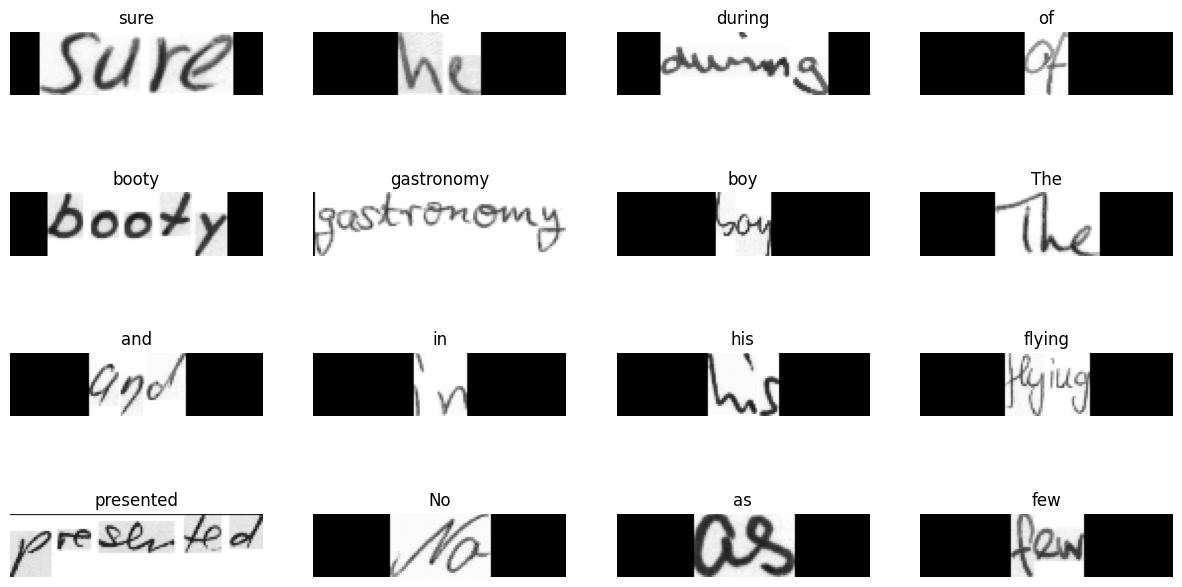

In [19]:
for data in train_ds.take(1):
    images, labels = data["image"], data["label"]

    _, ax = plt.subplots(4, 4, figsize=(15, 8))

    for i in range(16):
        img = images[i]
        img = tf.image.flip_left_right(img)
        img = ops.transpose(img, (1, 0, 2))
        img = (img * 255.0).numpy().clip(0, 255).astype(np.uint8)
        img = img[:, :, 0]

        # Gather indices where label!= padding_token.
        label = labels[i]
        indices = tf.gather(label, tf.where(tf.math.not_equal(label, padding_token)))
        # Convert to string.
        label = tf.strings.reduce_join(num_to_char(indices))
        label = label.numpy().decode("utf-8")

        ax[i // 4, i % 4].imshow(img, cmap="gray")
        ax[i // 4, i % 4].set_title(label)
        ax[i // 4, i % 4].axis("off")


plt.show()

You will notice that the content of original image is kept as faithful as possible and has
been padded accordingly.

## Model

Our model will use the CTC loss as an endpoint layer. For a detailed understanding of the
CTC loss, refer to [this post](https://distill.pub/2017/ctc/).

In [20]:
class CTCLayer(keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = ops.cast(ops.shape(y_true)[0], dtype="int64")
        input_length = ops.cast(ops.shape(y_pred)[1], dtype="int64")
        label_length = ops.cast(ops.shape(y_true)[1], dtype="int64")

        input_length = input_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)

        # At test time, just return the computed predictions.
        return y_pred


def build_model():
    # Inputs to the model
    input_img = keras.Input(shape=(image_width, image_height, 1), name="image")
    labels = keras.layers.Input(name="label", shape=(None,))

    # First conv block.
    x = keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same",
        name="Conv1",
    )(input_img)
    x = keras.layers.MaxPooling2D((2, 2), name="pool1")(x)

    # Second conv block.
    x = keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same",
        name="Conv2",
    )(x)
    x = keras.layers.MaxPooling2D((2, 2), name="pool2")(x)

    # We have used two max pool with pool size and strides 2.
    # Hence, downsampled feature maps are 4x smaller. The number of
    # filters in the last layer is 64. Reshape accordingly before
    # passing the output to the RNN part of the model.
    new_shape = ((image_width // 4), (image_height // 4) * 64)
    x = keras.layers.Reshape(target_shape=new_shape, name="reshape")(x)
    x = keras.layers.Dense(64, activation="relu", name="dense1")(x)
    x = keras.layers.Dropout(0.2)(x)

    # RNNs.
    x = keras.layers.Bidirectional(
        keras.layers.LSTM(128, return_sequences=True, dropout=0.25)
    )(x)
    x = keras.layers.Bidirectional(
        keras.layers.LSTM(64, return_sequences=True, dropout=0.25)
    )(x)

    # +2 is to account for the two special tokens introduced by the CTC loss.
    # The recommendation comes here: https://git.io/J0eXP.
    x = keras.layers.Dense(
        len(char_to_num.get_vocabulary()) + 2, activation="softmax", name="dense2"
    )(x)

    # Add CTC layer for calculating CTC loss at each step.
    output = CTCLayer(name="ctc_loss")(labels, x)

    # Define the model.
    model = keras.models.Model(
        inputs=[input_img, labels], outputs=output, name="handwriting_recognizer"
    )
    # Optimizer.
    opt = keras.optimizers.Adam()
    # Compile the model and return.
    model.compile(optimizer=opt)
    return model


# Get the model.
model = build_model()
model.summary()

Model: "handwriting_recognizer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 128, 32,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 32,   │        320 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 16,    │          0 │ Conv1[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv2 (Conv2D)      │ (None, 64, 16,    │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 32, 8, 64) │          0 │ Conv2[0][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 512)   │          0 │ pool2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 32, 64)    │     32,832 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 64)    │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 32, 256)   │    197,632 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 32, 128)   │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 32, 81)    │     10,449 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc_loss (CTCLayer) │ (None, 32, 81)    │          0 │ label[0][0],      │
│                     │                   │            │ dense2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 424,081 (1.62 MB)

 Trainable params: 424,081 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

## Evaluation metric

[Edit Distance](https://en.wikipedia.org/wiki/Edit_distance)
is the most widely used metric for evaluating OCR models. In this section, we will
implement it and use it as a callback to monitor our model.

We first segregate the validation images and their labels for convenience.

In [21]:
validation_images = []
validation_labels = []

for batch in validation_ds:
    validation_images.append(batch["image"])
    validation_labels.append(batch["label"])

Now, we create a callback to monitor the edit distances.

In [22]:
def calculate_edit_distance(labels, predictions):
    # Get a single batch and convert its labels to sparse tensors.
    saprse_labels = ops.cast(tf.sparse.from_dense(labels), dtype=tf.int64)

    # Make predictions and convert them to sparse tensors.
    input_len = np.ones(predictions.shape[0]) * predictions.shape[1]
    predictions_decoded = keras.ops.nn.ctc_decode(
        predictions, sequence_lengths=input_len
    )[0][0][:, :max_len]
    sparse_predictions = ops.cast(
        tf.sparse.from_dense(predictions_decoded), dtype=tf.int64
    )

    # Compute individual edit distances and average them out.
    edit_distances = tf.edit_distance(
        sparse_predictions, saprse_labels, normalize=False
    )
    return tf.reduce_mean(edit_distances)


class EditDistanceCallback(keras.callbacks.Callback):
    def __init__(self, pred_model):
        super().__init__()
        self.prediction_model = pred_model

    def on_epoch_end(self, epoch, logs=None):
        edit_distances = []

        for i in range(len(validation_images)):
            labels = validation_labels[i]
            predictions = self.prediction_model.predict(validation_images[i])
            edit_distances.append(calculate_edit_distance(labels, predictions).numpy())

        print(
            f"Mean edit distance for epoch {epoch + 1}: {np.mean(edit_distances):.4f}"
        )

## Training

Now we are ready to kick off model training.

In [23]:
epochs = 10  # To get good results this should be at least 50.

model = build_model()
prediction_model = keras.models.Model(
    model.get_layer(name="image").output, model.get_layer(name="dense2").output
)
edit_distance_callback = EditDistanceCallback(prediction_model)

# Train the model.
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    callbacks=[edit_distance_callback],
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


## Inference

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


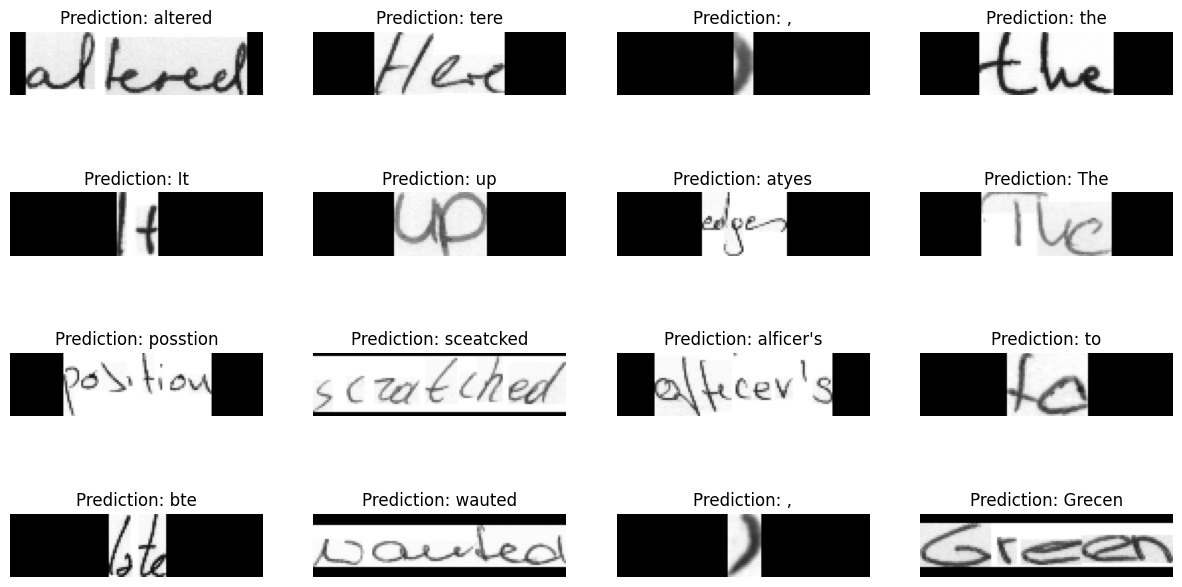

In [24]:
# A utility function to decode the output of the network.
def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    # Use greedy search. For complex tasks, you can use beam search.
    results = keras.ops.nn.ctc_decode(pred, sequence_lengths=input_len)[0][0][
        :, :max_len
    ]
    # Iterate over the results and get back the text.
    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = (
            tf.strings.reduce_join(num_to_char(res))
            .numpy()
            .decode("utf-8")
            .replace("[UNK]", "")
        )
        output_text.append(res)
    return output_text


#  Let's check results on some test samples.
for batch in test_ds.take(1):
    batch_images = batch["image"]
    _, ax = plt.subplots(4, 4, figsize=(15, 8))

    preds = prediction_model.predict(batch_images)
    pred_texts = decode_batch_predictions(preds)

    for i in range(16):
        img = batch_images[i]
        img = tf.image.flip_left_right(img)
        img = ops.transpose(img, (1, 0, 2))
        img = (img * 255.0).numpy().clip(0, 255).astype(np.uint8)
        img = img[:, :, 0]

        title = f"Prediction: {pred_texts[i]}"
        ax[i // 4, i % 4].imshow(img, cmap="gray")
        ax[i // 4, i % 4].set_title(title)
        ax[i // 4, i % 4].axis("off")

plt.show()

## Deploying the model as an API

To create an API for the model, you first need to save the trained `prediction_model`. Once saved, you can deploy it using various methods:

1.  **TensorFlow Serving**: For production environments, TensorFlow Serving is a high-performance serving system for machine learning models.
2.  **Web Frameworks (e.g., Flask, FastAPI)**: For simpler deployments or custom logic, you can build a web API using Python frameworks like Flask or FastAPI to load the model and make predictions.

Let's start by saving the `prediction_model`.

In [26]:
model_save_path = "./handwriting_recognition_model.keras"
prediction_model.save(model_save_path)

print(f"Model saved to: {model_save_path}")

Model saved to: ./handwriting_recognition_model.keras


In [7]:
import keras

# Define CTCLayer again as it's a custom object needed for loading
class CTCLayer(keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = ops.cast(ops.shape(y_true)[0], dtype="int64")
        input_length = ops.cast(ops.shape(y_pred)[1], dtype="int64")
        label_length = ops.cast(ops.shape(y_true)[1], dtype="int64")

        input_length = input_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

model_save_path = "./handwriting_recognition_model.keras"
loaded_prediction_model = keras.models.load_model(model_save_path, custom_objects={'CTCLayer': CTCLayer})

print("Model loaded successfully!")
loaded_prediction_model.summary()

Model loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 32, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 64, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 32, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 32, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 32, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 32, 81)         │        10,449 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,081 (1.62 MB)

 Trainable params: 424,081 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

Now that the model is saved, you can load it and use it for inference in a serving environment. Here's how you might load it back:

```python
import keras
loaded_model = keras.models.load_model(model_save_path, custom_objects={'CTCLayer': CTCLayer})

# Example of using the loaded model for prediction
# For simplicity, we'll use a sample from the test_ds
for batch in test_ds.take(1):
    sample_images = batch["image"]
    predictions = loaded_model.predict(sample_images)
    decoded_predictions = decode_batch_predictions(predictions)
    print("Decoded predictions from loaded model:", decoded_predictions[:5])
```

### FastAPI Application to Load and Serve the Model

To create a simple FastAPI application, we'll first define the application code and then provide instructions on how to run it.

In [28]:
import uvicorn
from fastapi import FastAPI, APIRouter
from contextlib import asynccontextmanager
import keras
import tensorflow as tf

# Assuming CTCLayer is defined in the same scope where the model was built
# If it's in a separate file, you would import it.
class CTCLayer(keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = ops.cast(ops.shape(y_true)[0], dtype="int64")
        input_length = ops.cast(ops.shape(y_pred)[1], dtype="int64")
        label_length = ops.cast(ops.shape(y_true)[1], dtype="int64")

        input_length = input_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

model_save_path = "./handwriting_recognition_model.keras"
loaded_model = None

@asynccontextmanager
async def lifespan(app: FastAPI):
    global loaded_model
    try:
        # Load the model with custom objects
        loaded_model = keras.models.load_model(model_save_path, custom_objects={'CTCLayer': CTCLayer})
        print("Model loaded successfully!")
    except Exception as e:
        print(f"Error loading model: {e}")
    yield
    # Clean up (optional) - e.g., close database connections
    print("Application shutting down.")


app = FastAPI(lifespan=lifespan)


@app.get("/health")
async def health_check():
    if loaded_model:
        return {"status": "ok", "message": "Model loaded and ready"}
    else:
        return {"status": "error", "message": "Model not loaded"}

@app.post("/predict")
async def predict_handwriting(image_data: dict): # Replace dict with a proper Pydantic model for image input
    # In a real scenario, you would process image_data here
    # For this skeleton, we just confirm model is loaded
    if loaded_model:
        # Example: predictions = loaded_model.predict(processed_image_data)
        # decoded_predictions = decode_batch_predictions(predictions)
        return {"prediction": "Model is ready for predictions", "model_loaded": True}
    else:
        return {"prediction": "Model not loaded", "model_loaded": False}

# To run this FastAPI app in Colab, you typically need to use ngrok
# or a similar tool to expose the port. First, install uvicorn and python-multipart.
# !pip install uvicorn python-multipart

# Then, in a separate cell, you would run:
# !uvicorn main:app --host 0.0.0.0 --port 8000
# And use ngrok or localtunnel for external access if needed.

To run this FastAPI application in Google Colab:

1.  **Install necessary libraries**: Run the following in a code cell:
    ```python
    !pip install uvicorn python-multipart
    ```
2.  **Save the FastAPI code**: Since Colab doesn't directly support running a script like `uvicorn main:app`, you would typically save the Python code above to a file (e.g., `main.py`). However, for a simple demonstration, you can run `uvicorn` directly from Colab:
    ```python
    import nest_asyncio
    nest_asyncio.apply()

    # Make sure the 'app' object from the previous cell is defined
    !uvicorn __main__:app --host 0.0.0.0 --port 8000 &
    ```
    The `&` at the end runs it in the background.

3.  **Expose the server (Optional, for external access)**: If you need to access your FastAPI server from outside Colab, you can use `ngrok`. First, install it:
    ```python
    !pip install pyngrok
    ```
    Then, run this code to get a public URL:
    ```python
    from pyngrok import ngrok
    public_url = ngrok.connect(8000)
    print(f"Public URL: {public_url}")
    ```
    You can then access your API using this public URL.

In [30]:
import nest_asyncio
nest_asyncio.apply()

# Make sure the 'app' object from the previous cell is defined
!uvicorn __main__:app --host 0.0.0.0 --port 8000 &

ERROR:    Error loading ASGI app. Attribute "app" not found in module "__main__".


In [33]:
import nest_asyncio
import asyncio
nest_asyncio.apply()

import uvicorn
from fastapi import FastAPI, APIRouter, File, UploadFile
from contextlib import asynccontextmanager
import keras
import tensorflow as tf
import numpy as np
from keras import ops

# Global variables from the original notebook context needed for preprocessing and decoding
# These values should ideally be loaded or passed more robustly in a production API
image_width = 128
image_height = 32
max_len = 21 # From the original notebook: Maximum length of cleaned labels
padding_token = 99 # From the original notebook

# Re-define StringLookup for char_to_num and num_to_char
# This assumes 'characters' vocabulary was previously established in the notebook
# and we need to recreate the mappers with the same vocabulary.
# For a true API, the vocabulary would be saved and loaded.

# Placeholder for characters and mappers, assuming they were established earlier
# In a real API, these would be loaded from a saved state or configuration
characters = [
    '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'
]

# Mapping characters to integers.
char_to_num = keras.layers.StringLookup(vocabulary=list(characters), mask_token=None)
# Mapping integers back to original characters.
num_to_char = keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
)


# Helper functions from the notebook, adapted for API context
def distortion_free_resize(image, img_size):
    w, h = img_size
    image = tf.image.resize(image, size=(h, w), preserve_aspect_ratio=True)

    # Check the amount of padding needed to be done.
    pad_height = h - ops.shape(image)[0]
    pad_width = w - ops.shape(image)[1]

    # Only necessary if you want to do same amount of padding on both sides.
    if pad_height % 2 != 0:
        height = pad_height // 2
        pad_height_top = height + 1
        pad_height_bottom = height
    else:
        pad_height_top = pad_height_bottom = pad_height // 2

    if pad_width % 2 != 0:
        width = pad_width // 2
        pad_width_left = width + 1
        pad_width_right = width
    else:
        pad_width_left = pad_width_right = pad_width // 2

    image = tf.pad(
        image,
        paddings=[
            [pad_height_top, pad_height_bottom],
            [pad_width_left, pad_width_right],
            [0, 0],
        ],
    )

    image = ops.transpose(image, (1, 0, 2))
    image = tf.image.flip_left_right(image)
    return image

def preprocess_image_for_api(image_bytes, img_size=(image_width, image_height)):
    image = tf.io.decode_png(image_bytes, 1)
    image = distortion_free_resize(image, img_size)
    image = ops.cast(image, tf.float32) / 255.0
    return tf.expand_dims(image, axis=0) # Add batch dimension

def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    # Use greedy search. For complex tasks, you can use beam search.
    results = keras.ops.nn.ctc_decode(pred, sequence_lengths=input_len)[0][0][
        :, :max_len
    ]
    # Iterate over the results and get back the text.
    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = (
            tf.strings.reduce_join(num_to_char(res))
            .numpy()
            .decode("utf-8")
            .replace("[UNK]", "")
        )
        output_text.append(res)
    return output_text


# Assuming CTCLayer is defined in the same scope where the model was built
# If it's in a separate file, you would import it.
class CTCLayer(keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = ops.cast(ops.shape(y_true)[0], dtype="int64")
        input_length = ops.cast(ops.shape(y_pred)[1], dtype="int64")
        label_length = ops.cast(ops.shape(y_true)[1], dtype="int64")

        input_length = input_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

model_save_path = "./handwriting_recognition_model.keras"
loaded_model = None

@asynccontextmanager
async def lifespan(app: FastAPI):
    global loaded_model
    try:
        # Load the model with custom objects
        loaded_model = keras.models.load_model(model_save_path, custom_objects={'CTCLayer': CTCLayer})
        print("Model loaded successfully!")
    except Exception as e:
        print(f"Error loading model: {e}")
    yield
    # Clean up (optional) - e.g., close database connections
    print("Application shutting down.")


app = FastAPI(lifespan=lifespan)


@app.get("/health")
async def health_check():
    if loaded_model:
        return {"status": "ok", "message": "Model loaded and ready"}
    else:
        return {"status": "error", "message": "Model not loaded"}

@app.post("/predict")
async def predict_handwriting(file: UploadFile = File(...)):
    if not loaded_model:
        return {"prediction": "Model not loaded", "model_loaded": False}

    try:
        contents = await file.read()
        # Preprocess the image
        preprocessed_image = preprocess_image_for_api(contents)

        # Make prediction
        predictions = loaded_model.predict(preprocessed_image)

        # Decode predictions
        decoded_predictions = decode_batch_predictions(predictions)

        return {"prediction": decoded_predictions[0], "model_loaded": True}
    except Exception as e:
        return {"error": str(e), "model_loaded": True}

# Run Uvicorn in a background task using asyncio.create_task
asyncio.create_task(uvicorn.Server(config=uvicorn.Config(app, host="0.0.0.0", port=8000)).serve())
print("FastAPI application started in the background on http://0.0.0.0:8000")

FastAPI application started in the background on http://0.0.0.0:8000


In [3]:
import requests
import os
import time # Import the time module

# Assuming the FastAPI app is running on localhost:8000
# You might need to use an ngrok URL if accessing from outside Colab
api_url = "http://localhost:8000/predict"

# Original line that caused NameError:
# sample_image_path = test_img_paths[0]

# Fixing NameError: 'test_img_paths' was not defined.
# This usually means that the data loading and processing cells (like CXsT4EUM431A)
# which define 'test_img_paths' were not executed or the kernel was reset.
# For immediate testing, we will use a known sample image path from the dataset.
# For proper use, please ensure all data loading cells are run.
sample_image_path = "data/words/a01/a01-000u/a01-000u-00-00.png" # Example path from the dataset

# Verify the file exists
if not os.path.exists(sample_image_path):
    print(f"Error: Image file not found at {sample_image_path}. Please check if the data was extracted correctly or run data loading cells.")
else:
    print(f"Attempting to predict for image: {sample_image_path}")

    # Add a small delay to ensure the FastAPI server is fully initialized
    print("Waiting 5 seconds for the FastAPI server to initialize...")
    time.sleep(5)

    # Open the image file in binary mode
    with open(sample_image_path, "rb") as f:
        files = {"file": (os.path.basename(sample_image_path), f, "image/png")}
        try:
            response = requests.post(api_url, files=files)
            response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)
            print("Prediction Response:")
            print(response.json())
        except requests.exceptions.ConnectionError:
            print("Error: Could not connect to the FastAPI server. Make sure it's running.")
        except requests.exceptions.RequestException as e:
            print(f"An error occurred: {e}")

Attempting to predict for image: data/words/a01/a01-000u/a01-000u-00-00.png
Waiting 5 seconds for the FastAPI server to initialize...
Error: Could not connect to the FastAPI server. Make sure it's running.


In [5]:
!pip install pyngrok -q

from pyngrok import ngrok
import os

# Terminate any existing ngrok tunnels
ngrok.kill()

# Get ngrok token from environment variable or set it manually
# It's highly recommended to store your ngrok token securely, e.g., in Colab secrets.
ngrok_token = os.environ.get("NGROK_AUTH_TOKEN", "YOUR_NGROK_AUTH_TOKEN")
ngrok.set_auth_token(ngrok_token)

# Open a tunnel to port 8000
public_url = ngrok.connect(8000)
print(f"Ngrok Tunnel URL: {public_url}")
print("Please copy this URL and use it to replace 'http://localhost:8000' in your api_url variable.")

ERROR:pyngrok.process.ngrok:t=2026-04-26T13:47:34+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NGROK_AUTH_TOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NGROK_AUTH_TOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.

In [6]:
from google.colab import userdata
from pyngrok import ngrok
import os

# Terminate any existing ngrok tunnels
ngrok.kill()

# Retrieve ngrok token from Colab secrets
ngrok_token = userdata.get('NGROK_AUTH_TOKEN')

if ngrok_token:
    ngrok.set_auth_token(ngrok_token)
    # Open a tunnel to port 8000
    public_url = ngrok.connect(8000)
    print(f"Ngrok Tunnel URL: {public_url}")
    print("Please copy this URL and use it to replace 'http://localhost:8000' in your api_url variable in the testing cell.")
else:
    print("Error: NGROK_AUTH_TOKEN not found in Colab secrets. Please add it and enable notebook access.")

SecretNotFoundError: Secret NGROK_AUTH_TOKEN does not exist.

After running the cell above, `ngrok` will provide a public URL. You need to replace `http://localhost:8000` with this `ngrok` URL in the `api_url` variable of your testing code. Then, re-run the testing cell to send requests through the `ngrok` tunnel.

This code snippet performs the following:

1.  **`api_url`**: Defines the URL of your `/predict` endpoint. If you used `ngrok` for external access, replace `http://localhost:8000` with your `ngrok` public URL.
2.  **`sample_image_path`**: Takes the path of the first image from your `test_img_paths` list to use as input.
3.  **File Handling**: Opens the image file in binary read mode (`"rb"`).
4.  **`requests.post`**: Sends an HTTP `POST` request to the API. The `files` parameter is used to send the image as a multipart-formdata. The tuple `(os.path.basename(sample_image_path), f, "image/png")` provides the filename, the file-like object, and the content type.
5.  **Error Handling**: Includes `try-except` blocks to catch potential connection errors or other request-related issues.
6.  **Print Response**: Prints the JSON response received from the FastAPI server, which should contain the predicted text.

In [8]:
from google.colab import files
import requests
import os
import time
import io

# Ensure the FastAPI server is running before executing this cell
print("Please ensure the FastAPI server is running (cell cbfa2d8f). Waiting 5 seconds...")
time.sleep(5)

# The API URL for your local FastAPI server
api_url = "http://localhost:8000/predict"

# Upload a file from your local system
uploaded = files.upload()

if not uploaded:
    print("No file uploaded. Please upload an image file.")
else:
    for filename, content in uploaded.items():
        print(f"Uploaded file: {filename}")

        # Prepare the file for the POST request
        # requests expects a file-like object or bytes, along with filename and content type
        files_to_send = {'file': (filename, io.BytesIO(content), 'image/png')}

        try:
            response = requests.post(api_url, files=files_to_send)
            response.raise_for_status()  # Raise an exception for HTTP errors (4xx or 5xx)
            print("Prediction Response:")
            print(response.json())
        except requests.exceptions.ConnectionError:
            print("Error: Could not connect to the FastAPI server. Make sure it's running (cell cbfa2d8f).")
        except requests.exceptions.RequestException as e:
            print(f"An error occurred: {e}")
        except Exception as e:
            print(f"An unexpected error occurred: {e}")


Please ensure the FastAPI server is running (cell cbfa2d8f). Waiting 5 seconds...


Saving a01-000u-01-04.png to a01-000u-01-04 (1).png
Uploaded file: a01-000u-01-04 (1).png
Error: Could not connect to the FastAPI server. Make sure it's running (cell cbfa2d8f).


Model loaded successfully for direct prediction!
Please upload an image file for prediction:


Saving a01-000u-00-05.png to a01-000u-00-05.png
Uploaded file: a01-000u-00-05.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step


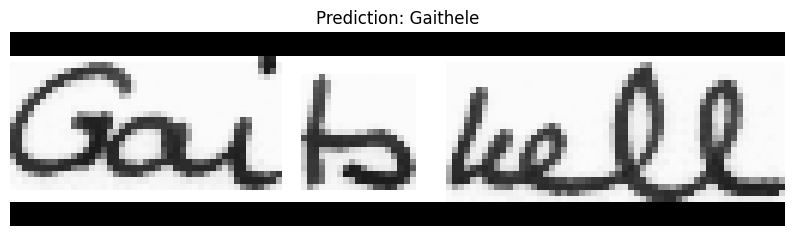


Direct Prediction for a01-000u-00-05.png: Gaithele


In [11]:
from google.colab import files
import tensorflow as tf
import numpy as np
import io
import keras
from keras import ops
import matplotlib.pyplot as plt

# --- Re-define global variables and mappers needed for direct prediction ---
# These values are derived from earlier cells (e.g., bJlXH_GJ431B, ArYSKU-u431I)
image_width = 128
image_height = 32
max_len = 21 # Maximum length of cleaned labels
padding_token = 99

# Re-create the 'characters' vocabulary and StringLookup layers
# In a real application, these would be saved and loaded from disk.
characters = [
    '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'
]

char_to_num = keras.layers.StringLookup(vocabulary=list(characters), mask_token=None)
num_to_char = keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
)

# --- Helper functions (copied from earlier cells for self-containment) ---
class CTCLayer(keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = ops.cast(ops.shape(y_true)[0], dtype="int64")
        input_length = ops.cast(ops.shape(y_pred)[1], dtype="int64")
        label_length = ops.cast(ops.shape(y_true)[1], dtype="int64")

        input_length = input_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * ops.ones(shape=(batch_len, 1), dtype="int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

def distortion_free_resize(image, img_size):
    w, h = img_size
    image = tf.image.resize(image, size=(h, w), preserve_aspect_ratio=True)

    pad_height = h - ops.shape(image)[0]
    pad_width = w - ops.shape(image)[1]

    if pad_height % 2 != 0:
        height = pad_height // 2
        pad_height_top = height + 1
        pad_height_bottom = height
    else:
        pad_height_top = pad_height_bottom = pad_height // 2

    if pad_width % 2 != 0:
        width = pad_width // 2
        pad_width_left = width + 1
        pad_width_right = width
    else:
        pad_width_left = pad_width_right = pad_width // 2

    image = tf.pad(
        image,
        paddings=[
            [pad_height_top, pad_height_bottom],
            [pad_width_left, pad_width_right],
            [0, 0],
        ],
    )
    image = ops.transpose(image, (1, 0, 2))
    image = tf.image.flip_left_right(image)
    return image

def preprocess_image_for_direct_prediction(image_bytes, img_size=(image_width, image_height)):
    image = tf.io.decode_png(image_bytes, 1)
    image = distortion_free_resize(image, img_size)
    image = ops.cast(image, tf.float32) / 255.0
    return tf.expand_dims(image, axis=0) # Add batch dimension

def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = keras.ops.nn.ctc_decode(pred, sequence_lengths=input_len)[0][0][
        :, :max_len
    ]
    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = (
            tf.strings.reduce_join(num_to_char(res))
            .numpy()
            .decode("utf-8")
            .replace("[UNK]", "")
        )
        output_text.append(res)
    return output_text


# --- Load the saved model ---
model_save_path = "./handwriting_recognition_model.keras"
loaded_model_direct = None
try:
    # Use the globally available CTCLayer if defined in current session
    loaded_model_direct = keras.models.load_model(model_save_path, custom_objects={'CTCLayer': CTCLayer})
    print("Model loaded successfully for direct prediction!")
except Exception as e:
    print(f"Error loading model for direct prediction: {e}")


# --- File upload and prediction logic ---
if loaded_model_direct:
    print("Please upload an image file for prediction:")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded. Please try again.")
    else:
        for filename, content in uploaded.items():
            print(f"Uploaded file: {filename}")
            try:
                # Preprocess the uploaded image
                preprocessed_image_tensor = preprocess_image_for_direct_prediction(content)

                # Make prediction
                predictions = loaded_model_direct.predict(preprocessed_image_tensor)

                # Decode predictions
                decoded_predictions = decode_batch_predictions(predictions)

                # Display the image and prediction
                plt.figure(figsize=(10, 4))
                img_to_display = tf.squeeze(preprocessed_image_tensor, axis=0) * 255.0 # Squeeze only batch dim
                img_to_display = tf.image.flip_left_right(img_to_display)
                img_to_display = ops.transpose(img_to_display, (1, 0, 2))
                img_to_display = img_to_display.numpy().clip(0, 255).astype(np.uint8)[:,:,0]

                plt.imshow(img_to_display, cmap="gray")
                plt.title(f"Prediction: {decoded_predictions[0]}")
                plt.axis("off")
                plt.show()

                print(f"\nDirect Prediction for {filename}: {decoded_predictions[0]}")
            except Exception as e:
                print(f"An error occurred during prediction: {e}")
else:
    print("Cannot proceed with prediction as the model could not be loaded.")

In [29]:
!pip install uvicorn python-multipart

In [12]:
!pip install flask flask-ngrok

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
model.save('/content/drive/MyDrive/ocr_model.keras')

In [16]:
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/ocr_model.keras',
    custom_objects={'CTCLayer': CTCLayer}
)

To get better results the model should be trained for at least 50 epochs.

## Final remarks

* The `prediction_model` is fully compatible with TensorFlow Lite. If you are interested,
you can use it inside a mobile application. You may find
[this notebook](https://github.com/tulasiram58827/ocr_tflite/blob/main/colabs/captcha_ocr_tflite.ipynb)
to be useful in this regard.
* Not all the training examples are perfectly aligned as observed in this example. This
can hurt model performance for complex sequences. To this end, we can leverage
Spatial Transformer Networks ([Jaderberg et al.](https://arxiv.org/abs/1506.02025))
that can help the model learn affine transformations that maximize its performance.